In [1]:
!pip install -q kagglehub

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'karlobasic'
os.environ['KAGGLE_KEY'] = 'KGAT_1bdeb74be3749cdcd52b1fc4724fb253'

In [3]:
import kagglehub

path = kagglehub.dataset_download("gpiosenka/sports-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sports-classification' dataset.
Path to dataset files: /kaggle/input/sports-classification


In [ ]:
!dir $path

EfficientNetB0-100-(224\ X\ 224)-\ 98.40.h5  sports.csv  test  train  valid


In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126


Looking in indexes: https://download.pytorch.org/whl/cu126


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import os
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
DATA_DIR = "/content/data"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [9]:
!cp -r /content/drive/MyDrive/data /content/

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=transform)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

num_classes = len(train_ds.classes)
num_classes

100

In [ ]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


In [12]:
def train_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(out, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / len(loader), correct / total

In [13]:
def eval_epoch(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            running_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / len(loader), correct / total

In [ ]:
import time
EPOCHS = 1000
patience = 5
best_val_loss = float('inf')
patience_counter = 0
val_losses = []

best_model_state = None

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, valid_loader)
    end = time.time()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f" Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f" Validation loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    print(f"Duration: {end-start} s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("Validation loss improved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

100%|██████████| 422/422 [00:34<00:00, 12.07it/s]


Epoch 1/1000
 Train loss: 3.0690, acc: 0.4864
 Validation loss: 2.5758, acc: 0.6020
Duration: 36.2891149520874 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [00:35<00:00, 11.81it/s]


Epoch 2/1000
 Train loss: 2.4403, acc: 0.6378
 Validation loss: 2.0342, acc: 0.7180
Duration: 36.923424243927 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [00:36<00:00, 11.50it/s]


...

Epoch 57/1000
 Train loss: 0.2304, acc: 0.9579
 Validation loss: 0.3282, acc: 0.9000
Duration: 36.5254340171814 s
No improvement (3/5)
----------------------------------------


100%|██████████| 422/422 [00:35<00:00, 11.91it/s]


Epoch 58/1000
 Train loss: 0.2316, acc: 0.9569
 Validation loss: 0.3245, acc: 0.8960
Duration: 36.68967032432556 s
No improvement (4/5)
----------------------------------------


100%|██████████| 422/422 [00:34<00:00, 12.17it/s]


Epoch 59/1000
 Train loss: 0.2226, acc: 0.9601
 Validation loss: 0.3264, acc: 0.9020
Duration: 36.114418029785156 s
No improvement (5/5)
----------------------------------------
Early stopping at epoch 59


In [ ]:
test_loss, test_acc = eval_epoch(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
for i in range(0, 59):
  print(f"Epoch: {i+1}: validation loss: {val_losses[i]}")

Test accuracy: 0.9260
Epoch: 1: validation loss: 2.5757783204317093
Epoch: 2: validation loss: 2.0342000126838684
Epoch: 3: validation loss: 1.6512816324830055
Epoch: 4: validation loss: 1.3845212012529373
Epoch: 5: validation loss: 1.204953659325838
Epoch: 6: validation loss: 1.0767848379909992
Epoch: 7: validation loss: 0.9757824316620827
Epoch: 8: validation loss: 0.8877782188355923
Epoch: 9: validation loss: 0.8247604072093964
Epoch: 10: validation loss: 0.7667501121759415
Epoch: 11: validation loss: 0.7280470207333565
Epoch: 12: validation loss: 0.6711400095373392
Epoch: 13: validation loss: 0.6312157046049833
Epoch: 14: validation loss: 0.6126898415386677
Epoch: 15: validation loss: 0.581494526937604
Epoch: 16: validation loss: 0.569146566092968
Epoch: 17: validation loss: 0.5461720246821642
Epoch: 18: validation loss: 0.5184700451791286
Epoch: 19: validation loss: 0.503550885245204
Epoch: 20: validation loss: 0.4937025774270296
Epoch: 21: validation loss: 0.4757992308586836
Epoc

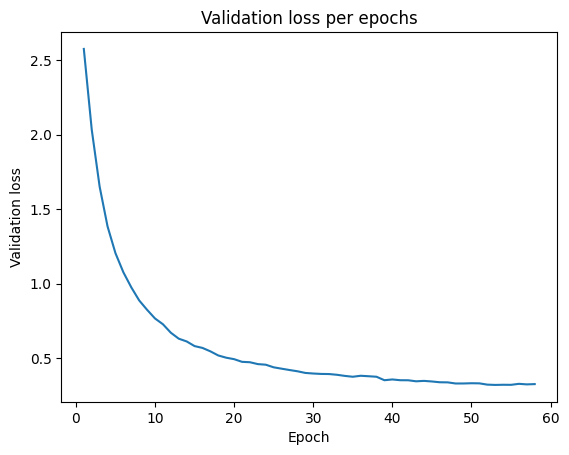

In [53]:
import matplotlib.pyplot as plt

val_losses = [2.5757783204317093, 2.0342000126838684, 1.6512816324830055, 1.3845212012529373, 1.204953659325838, 1.0767848379909992, 0.9757824316620827, 0.8877782188355923,  0.8247604072093964, 0.7667501121759415, 0.7280470207333565, 0.6711400095373392, 0.6312157046049833, 0.6126898415386677, 0.581494526937604,  0.569146566092968, 0.5461720246821642, 0.5184700451791286, 0.503550885245204, 0.4937025774270296, 0.4757992308586836, 0.47311499156057835, 0.46057145204395056, 0.456545852124691, 0.4389934241771698, 0.42988689430058, 0.42089436389505863, 0.412519171833992, 0.401380255818367, 0.39739955868571997, 0.39469245448708534, 0.39385107066482306, 0.38892287854105234, 0.3813975816592574, 0.37570289336144924, 0.38232925068587065, 0.37914992962032557, 0.3757244423031807, 0.35239643324166536, 0.3575742784887552, 0.3524354649707675, 0.3521273070946336, 0.3451880821958184, 0.3479674383997917, 0.34400133043527603, 0.3387294430285692, 0.3380040703341365, 0.3304643677547574, 0.33056439086794853, 0.3321694992482662, 0.33140653651207685, 0.3228446636348963, 0.320880763232708, 0.3219177043065429, 0.3214759789407253, 0.3282038811594248, 0.32451330590993166, 0.32639775797724724]

x = []

for i in range (0,58):
  x.append(i+1)

plt.plot(x, val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss per epochs")
plt.show()


In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, preds = torch.max(out, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

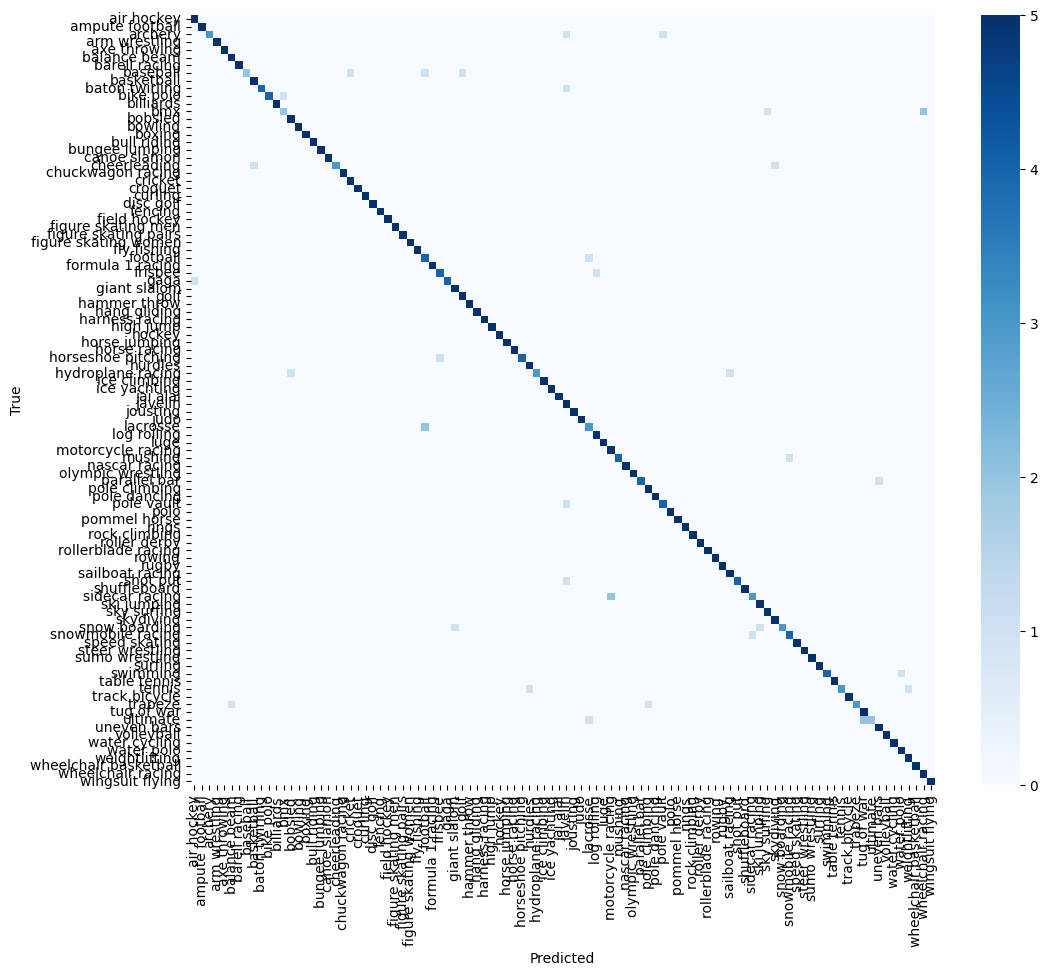

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
class_names = train_ds.classes

for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]

    print(f"\nClass: {class_name}")
    print(f"  Total samples : {total}")
    print(f"  Correct hits  : {correct}")

    errors = cm[i].copy()
    errors[i] = 0

    if errors.sum() == 0:
        print("  Incorrect: 0")
        continue

    print("  Misclassified as:")
    for j, count in enumerate(errors):
        if count > 0:
            print(f"    → {class_names[j]} : {count}")


Class: air hockey
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: ampute football
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: archery
  Total samples : 5
  Correct hits  : 3
  Misclassified as:
    → javelin : 1
    → pole vault : 1

Class: arm wrestling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: axe throwing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: balance beam
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: barell racing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baseball
  Total samples : 5
  Correct hits  : 2
  Misclassified as:
    → cricket : 1
    → football : 1
    → golf : 1

Class: basketball
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baton twirling
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → javelin : 1

Class: bike polo
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → bmx : 1

Class: billiards
  Total samp

In [ ]:
misclassified = defaultdict(list)

for idx, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        img_path, _ = test_ds.samples[idx]

        true_name = test_ds.classes[true_label]
        pred_name = test_ds.classes[pred_label]

        misclassified[true_name].append({
            "image": img_path,
            "predicted": pred_name
        })

for true_class, items in misclassified.items():
    print(f"\nClass: {true_class}")
    print(f"  Misclassified samples: {len(items)}")

    for item in items:
        print(f"    Image: {item['image']}")
        print(f"      → Predicted as: {item['predicted']}")


Class: archery
  Misclassified samples: 2
    Image: /content/data/test/archery/2.jpg
      → Predicted as: pole vault
    Image: /content/data/test/archery/3.jpg
      → Predicted as: javelin

Class: baseball
  Misclassified samples: 3
    Image: /content/data/test/baseball/1.jpg
      → Predicted as: cricket
    Image: /content/data/test/baseball/2.jpg
      → Predicted as: golf
    Image: /content/data/test/baseball/3.jpg
      → Predicted as: football

Class: baton twirling
  Misclassified samples: 1
    Image: /content/data/test/baton twirling/5.jpg
      → Predicted as: javelin

Class: bike polo
  Misclassified samples: 1
    Image: /content/data/test/bike polo/1.jpg
      → Predicted as: bmx

Class: bmx
  Misclassified samples: 3
    Image: /content/data/test/bmx/1.jpg
      → Predicted as: wheelchair racing
    Image: /content/data/test/bmx/2.jpg
      → Predicted as: sky surfing
    Image: /content/data/test/bmx/5.jpg
      → Predicted as: wheelchair racing

Class: cheerleadi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, "/content/drive/MyDrive/resnet.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=eval_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

num_classes = len(train_ds.classes)
num_classes

100

In [16]:
model = models.resnet18(pretrained=True)

for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


In [21]:
import time
EPOCHS = 1000
patience = 5
best_val_loss = float('inf')
patience_counter = 0
val_losses_2 = []

best_model_state = None

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, valid_loader)
    end = time.time()
    val_losses_2.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f" Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f" Validation loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    print(f"Duration: {end-start} s")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("Validation loss improved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

100%|██████████| 422/422 [01:01<00:00,  6.82it/s]


Epoch 1/1000
 Train loss: 0.1180, acc: 0.9973
 Validation loss: 0.2688, acc: 0.9440
Duration: 63.03918099403381 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [01:02<00:00,  6.77it/s]


Epoch 2/1000
 Train loss: 0.0962, acc: 0.9986
 Validation loss: 0.2595, acc: 0.9420
Duration: 63.56274485588074 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [01:01<00:00,  6.85it/s]


...

Epoch 48/1000
 Train loss: 0.0001, acc: 1.0000
 Validation loss: 0.1264, acc: 0.9640
Duration: 62.91077947616577 s
No improvement (3/5)
----------------------------------------


100%|██████████| 422/422 [01:01<00:00,  6.86it/s]


Epoch 49/1000
 Train loss: 0.0001, acc: 1.0000
 Validation loss: 0.1272, acc: 0.9620
Duration: 62.76864266395569 s
No improvement (4/5)
----------------------------------------


100%|██████████| 422/422 [01:02<00:00,  6.73it/s]


Epoch 50/1000
 Train loss: 0.0002, acc: 1.0000
 Validation loss: 0.1228, acc: 0.9680
Duration: 63.921746253967285 s
No improvement (5/5)
----------------------------------------
Early stopping at epoch 50


In [22]:
test_loss, test_acc = eval_epoch(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
for i in range(0, 50):
  print(f"Epoch: {i+1}: validation loss: {val_losses_2[i]}")


Test accuracy: 0.9780
Epoch: 1: validation loss: 0.2687532287091017
Epoch: 2: validation loss: 0.25947890989482403
Epoch: 3: validation loss: 0.24043562775477767
Epoch: 4: validation loss: 0.23360625095665455
Epoch: 5: validation loss: 0.21837900509126484
Epoch: 6: validation loss: 0.2103280588053167
Epoch: 7: validation loss: 0.19940778124146163
Epoch: 8: validation loss: 0.19350776658393443
Epoch: 9: validation loss: 0.1886684480123222
Epoch: 10: validation loss: 0.18912386847659945
Epoch: 11: validation loss: 0.18394724885001779
Epoch: 12: validation loss: 0.17967817652970552
Epoch: 13: validation loss: 0.16855347249656916
Epoch: 14: validation loss: 0.16223191528115422
Epoch: 15: validation loss: 0.16086557658854872
Epoch: 16: validation loss: 0.16855356504675
Epoch: 17: validation loss: 0.16110342682804912
Epoch: 18: validation loss: 0.15317964204587042
Epoch: 19: validation loss: 0.1540652677649632
Epoch: 20: validation loss: 0.1488223628839478
Epoch: 21: validation loss: 0.14900

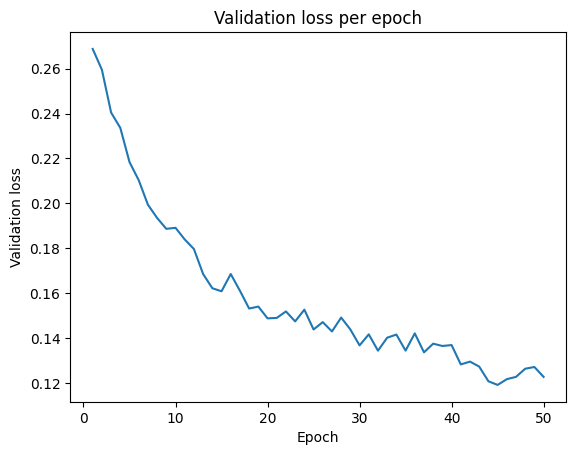

In [51]:
import matplotlib.pyplot as plt

x = []

for i in range (0,50):
  x.append(i+1)

plt.plot(x, val_losses_2)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss per epoch")
plt.show()

In [23]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, preds = torch.max(out, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

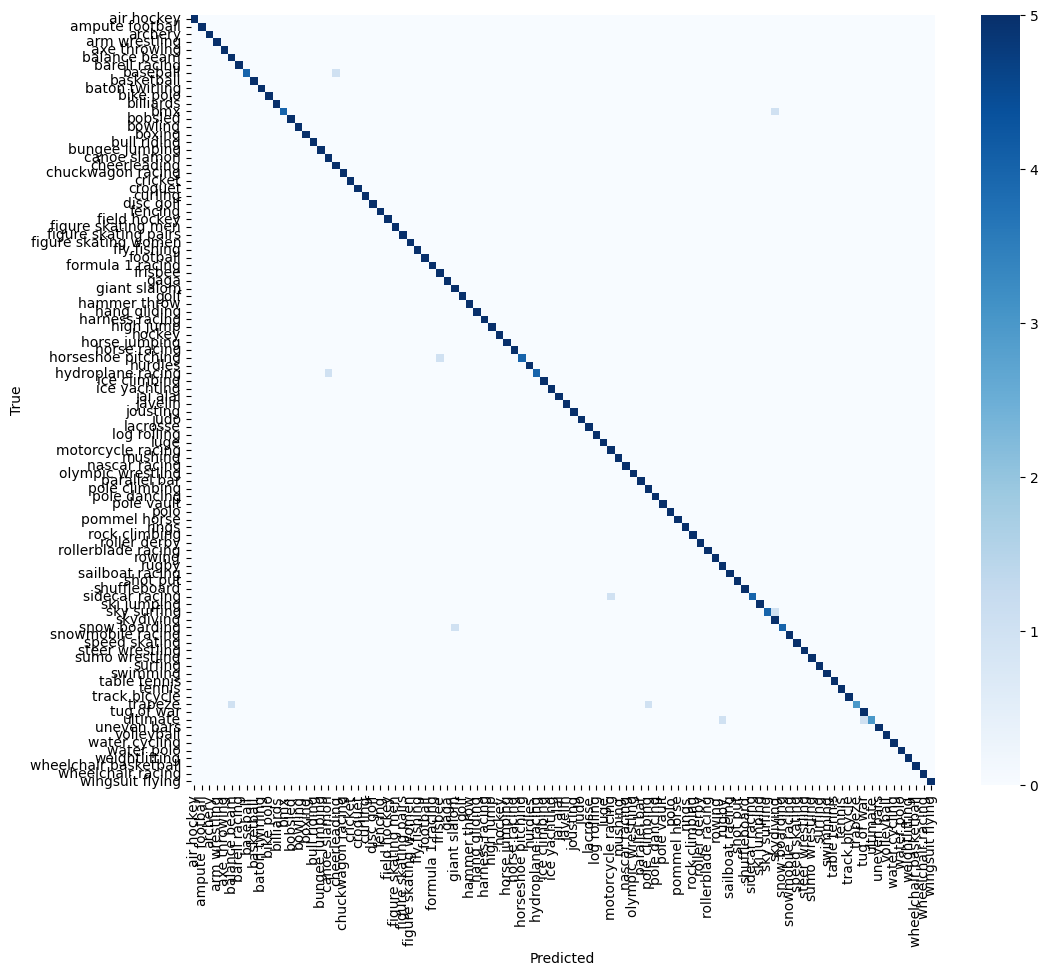

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
cm = confusion_matrix(all_labels, all_preds)
class_names = train_ds.classes

for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]

    print(f"\nClass: {class_name}")
    print(f"  Total samples : {total}")
    print(f"  Correct hits  : {correct}")

    errors = cm[i].copy()
    errors[i] = 0

    if errors.sum() == 0:
        print("  Incorrect: 0")
        continue

    print("  Misclassified as:")
    for j, count in enumerate(errors):
        if count > 0:
            print(f"    → {class_names[j]} : {count}")


Class: air hockey
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: ampute football
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: archery
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: arm wrestling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: axe throwing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: balance beam
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: barell racing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baseball
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → cheerleading : 1

Class: basketball
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baton twirling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: bike polo
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: billiards
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: bmx
  Total samples : 5
  Correct hits  : 4
  Misclassified as:


In [26]:
misclassified = defaultdict(list)

for idx, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        img_path, _ = test_ds.samples[idx]

        true_name = test_ds.classes[true_label]
        pred_name = test_ds.classes[pred_label]

        misclassified[true_name].append({
            "image": img_path,
            "predicted": pred_name
        })

for true_class, items in misclassified.items():
    print(f"\nClass: {true_class}")
    print(f"  Misclassified samples: {len(items)}")

    for item in items:
        print(f"    Image: {item['image']}")
        print(f"      → Predicted as: {item['predicted']}")


Class: baseball
  Misclassified samples: 1
    Image: /content/data/test/baseball/3.jpg
      → Predicted as: cheerleading

Class: bmx
  Misclassified samples: 1
    Image: /content/data/test/bmx/2.jpg
      → Predicted as: skydiving

Class: horseshoe pitching
  Misclassified samples: 1
    Image: /content/data/test/horseshoe pitching/4.jpg
      → Predicted as: frisbee

Class: hydroplane racing
  Misclassified samples: 1
    Image: /content/data/test/hydroplane racing/2.jpg
      → Predicted as: canoe slamon

Class: sidecar racing
  Misclassified samples: 1
    Image: /content/data/test/sidecar racing/3.jpg
      → Predicted as: motorcycle racing

Class: sky surfing
  Misclassified samples: 1
    Image: /content/data/test/sky surfing/1.jpg
      → Predicted as: skydiving

Class: snow boarding
  Misclassified samples: 1
    Image: /content/data/test/snow boarding/1.jpg
      → Predicted as: giant slalom

Class: trapeze
  Misclassified samples: 2
    Image: /content/data/test/trapeze/2

In [27]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, "/content/drive/MyDrive/resnet2.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=transform)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

num_classes = len(train_ds.classes)
num_classes

100

In [29]:
model = models.densenet121(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Linear(
    model.classifier.in_features, num_classes
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]


In [30]:
import time
EPOCHS = 1000
patience = 5
best_val_loss = float('inf')
patience_counter = 0
val_losses_3 = []

best_model_state = None

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, valid_loader)
    timee = time.time() - start
    val_losses_3.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f" Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f" Validation loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    print(f" Duration: {timee:.2f} s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("Validation loss improved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

100%|██████████| 422/422 [01:10<00:00,  6.01it/s]


Epoch 1/1000
 Train loss: 4.0992, acc: 0.1796
 Validation loss: 3.4872, acc: 0.4400
 Duration: 72.52 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [01:08<00:00,  6.16it/s]


Epoch 2/1000
 Train loss: 3.1016, acc: 0.5572
 Validation loss: 2.5995, acc: 0.7060
 Duration: 70.72 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [01:07<00:00,  6.29it/s]


...

Epoch 71/1000
 Train loss: 0.0904, acc: 0.9912
 Validation loss: 0.2019, acc: 0.9480
 Duration: 70.25 s
No improvement (3/5)
----------------------------------------


100%|██████████| 422/422 [01:08<00:00,  6.20it/s]


Epoch 72/1000
 Train loss: 0.0895, acc: 0.9913
 Validation loss: 0.1999, acc: 0.9440
 Duration: 70.41 s
No improvement (4/5)
----------------------------------------


100%|██████████| 422/422 [01:07<00:00,  6.22it/s]


Epoch 73/1000
 Train loss: 0.0831, acc: 0.9931
 Validation loss: 0.2045, acc: 0.9480
 Duration: 70.28 s
No improvement (5/5)
----------------------------------------
Early stopping at epoch 73


In [31]:
test_loss, test_acc = eval_epoch(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9540


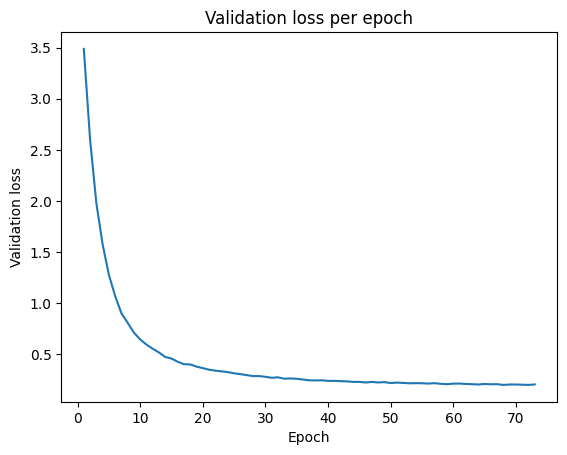

In [49]:
import matplotlib.pyplot as plt

x = []

for i in range (0,73):
  x.append(i+1)

plt.plot(x, val_losses_3)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss per epoch")
plt.show()

In [32]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, preds = torch.max(out, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

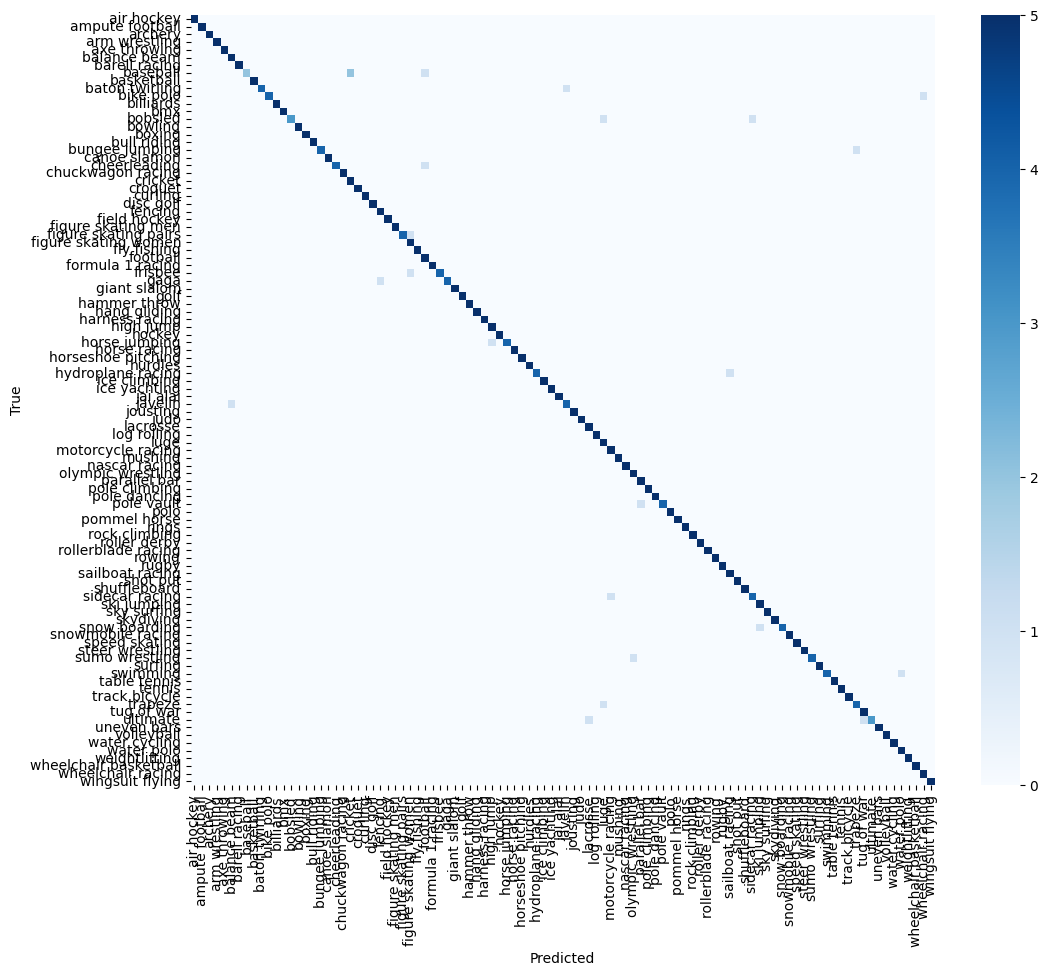

In [33]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [34]:
cm = confusion_matrix(all_labels, all_preds)
class_names = train_ds.classes

for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]

    print(f"\nClass: {class_name}")
    print(f"  Total samples : {total}")
    print(f"  Correct hits  : {correct}")

    errors = cm[i].copy()
    errors[i] = 0

    if errors.sum() == 0:
        print("  Incorrect: 0")
        continue

    print("  Misclassified as:")
    for j, count in enumerate(errors):
        if count > 0:
            print(f"    → {class_names[j]} : {count}")


Class: air hockey
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: ampute football
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: archery
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: arm wrestling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: axe throwing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: balance beam
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: barell racing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baseball
  Total samples : 5
  Correct hits  : 2
  Misclassified as:
    → cricket : 2
    → football : 1

Class: basketball
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baton twirling
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → javelin : 1

Class: bike polo
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → wheelchair racing : 1

Class: billiards
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

C

In [35]:
misclassified = defaultdict(list)

for idx, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        img_path, _ = test_ds.samples[idx]

        true_name = test_ds.classes[true_label]
        pred_name = test_ds.classes[pred_label]

        misclassified[true_name].append({
            "image": img_path,
            "predicted": pred_name
        })

for true_class, items in misclassified.items():
    print(f"\nClass: {true_class}")
    print(f"  Misclassified samples: {len(items)}")

    for item in items:
        print(f"    Image: {item['image']}")
        print(f"      → Predicted as: {item['predicted']}")


Class: baseball
  Misclassified samples: 3
    Image: /content/data/test/baseball/1.jpg
      → Predicted as: cricket
    Image: /content/data/test/baseball/2.jpg
      → Predicted as: cricket
    Image: /content/data/test/baseball/3.jpg
      → Predicted as: football

Class: baton twirling
  Misclassified samples: 1
    Image: /content/data/test/baton twirling/5.jpg
      → Predicted as: javelin

Class: bike polo
  Misclassified samples: 1
    Image: /content/data/test/bike polo/1.jpg
      → Predicted as: wheelchair racing

Class: bobsled
  Misclassified samples: 2
    Image: /content/data/test/bobsled/3.jpg
      → Predicted as: luge
    Image: /content/data/test/bobsled/4.jpg
      → Predicted as: sidecar racing

Class: bungee jumping
  Misclassified samples: 1
    Image: /content/data/test/bungee jumping/4.jpg
      → Predicted as: trapeze

Class: cheerleading
  Misclassified samples: 1
    Image: /content/data/test/cheerleading/2.jpg
      → Predicted as: football

Class: figure

In [36]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, "/content/drive/MyDrive/densenet.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
model = models.efficientnet_b0(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, num_classes
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier[1].parameters(),
    lr=1e-4
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


In [38]:
import time
EPOCHS = 1000
patience = 5
best_val_loss = float('inf')
patience_counter = 0
val_losses_4 = []
best_model_state = None

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, valid_loader)
    end = time.time()
    val_losses_4.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f" Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f" Validation loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    print(f" Duration: {end - start} s")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("Validation loss improved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

100%|██████████| 422/422 [00:43<00:00,  9.72it/s]


Epoch 1/1000
 Train loss: 4.1400, acc: 0.2221
 Validation loss: 3.6401, acc: 0.5320
 Duration: 44.81924080848694 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [00:40<00:00, 10.31it/s]


Epoch 2/1000
 Train loss: 3.3390, acc: 0.5514
 Validation loss: 2.9385, acc: 0.6560
 Duration: 42.27700757980347 s
Validation loss improved
----------------------------------------


100%|██████████| 422/422 [00:41<00:00, 10.21it/s]


...

Epoch 76/1000
 Train loss: 0.2337, acc: 0.9523
 Validation loss: 0.3576, acc: 0.8940
 Duration: 41.79326272010803 s
No improvement (3/5)
----------------------------------------


100%|██████████| 422/422 [00:40<00:00, 10.53it/s]


Epoch 77/1000
 Train loss: 0.2277, acc: 0.9545
 Validation loss: 0.3564, acc: 0.8980
 Duration: 41.668537616729736 s
No improvement (4/5)
----------------------------------------


100%|██████████| 422/422 [00:40<00:00, 10.52it/s]


Epoch 78/1000
 Train loss: 0.2247, acc: 0.9547
 Validation loss: 0.3627, acc: 0.8980
 Duration: 41.53653907775879 s
No improvement (5/5)
----------------------------------------
Early stopping at epoch 78


In [40]:
test_loss, test_acc = eval_epoch(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
for i in range(0, 78):
  print(f"Epoch: {i+1}: validation loss: {val_losses_4[i]}")


Test accuracy: 0.9000
Epoch: 1: validation loss: 3.6400838643312454
Epoch: 2: validation loss: 2.9385421723127365
Epoch: 3: validation loss: 2.338506132364273
Epoch: 4: validation loss: 1.9206544160842896
Epoch: 5: validation loss: 1.606731377542019
Epoch: 6: validation loss: 1.382438875734806
Epoch: 7: validation loss: 1.2525241263210773
Epoch: 8: validation loss: 1.1201164573431015
Epoch: 9: validation loss: 0.9990225918591022
Epoch: 10: validation loss: 0.9500070512294769
Epoch: 11: validation loss: 0.8769180420786142
Epoch: 12: validation loss: 0.8243988007307053
Epoch: 13: validation loss: 0.7555483430624008
Epoch: 14: validation loss: 0.7247589100152254
Epoch: 15: validation loss: 0.7140813395380974
Epoch: 16: validation loss: 0.6530602723360062
Epoch: 17: validation loss: 0.6656691320240498
Epoch: 18: validation loss: 0.6204235032200813
Epoch: 19: validation loss: 0.6018742471933365
Epoch: 20: validation loss: 0.5897816177457571
Epoch: 21: validation loss: 0.5658386088907719
Epo

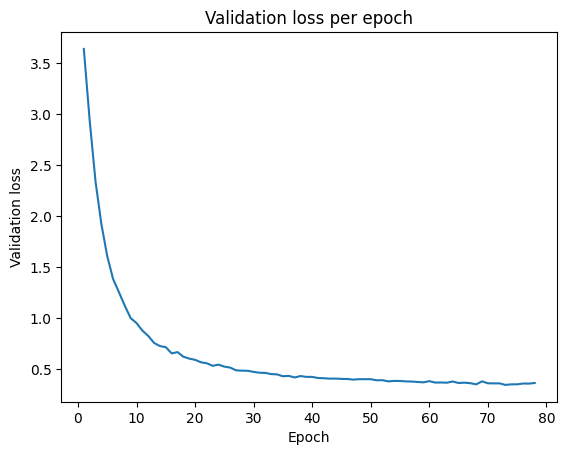

In [50]:
import matplotlib.pyplot as plt

x = []

for i in range (0,78):
  x.append(i+1)

plt.plot(x, val_losses_4)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss per epoch")
plt.show()

In [41]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, preds = torch.max(out, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

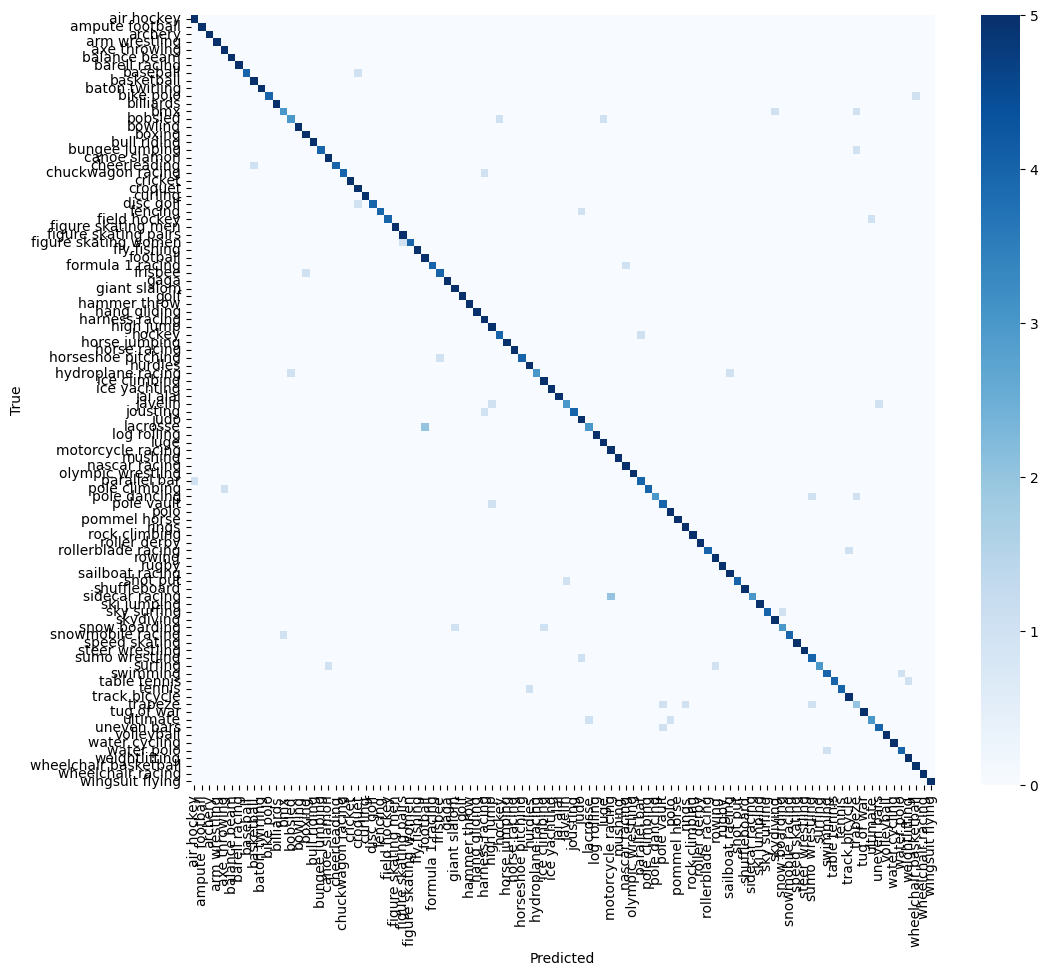

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [43]:
cm = confusion_matrix(all_labels, all_preds)
class_names = train_ds.classes

for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]

    print(f"\nClass: {class_name}")
    print(f"  Total samples : {total}")
    print(f"  Correct hits  : {correct}")

    errors = cm[i].copy()
    errors[i] = 0

    if errors.sum() == 0:
        print("  Incorrect: 0")
        continue

    print("  Misclassified as:")
    for j, count in enumerate(errors):
        if count > 0:
            print(f"    → {class_names[j]} : {count}")


Class: air hockey
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: ampute football
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: archery
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: arm wrestling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: axe throwing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: balance beam
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: barell racing
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baseball
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → croquet : 1

Class: basketball
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: baton twirling
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: bike polo
  Total samples : 5
  Correct hits  : 4
  Misclassified as:
    → wheelchair basketball : 1

Class: billiards
  Total samples : 5
  Correct hits  : 5
  Incorrect: 0

Class: bmx
  Total samples : 5
  Correc

In [44]:
misclassified = defaultdict(list)

for idx, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        img_path, _ = test_ds.samples[idx]

        true_name = test_ds.classes[true_label]
        pred_name = test_ds.classes[pred_label]

        misclassified[true_name].append({
            "image": img_path,
            "predicted": pred_name
        })

for true_class, items in misclassified.items():
    print(f"\nClass: {true_class}")
    print(f"  Misclassified samples: {len(items)}")

    for item in items:
        print(f"    Image: {item['image']}")
        print(f"      → Predicted as: {item['predicted']}")


Class: baseball
  Misclassified samples: 1
    Image: /content/data/test/baseball/3.jpg
      → Predicted as: croquet

Class: bike polo
  Misclassified samples: 1
    Image: /content/data/test/bike polo/2.jpg
      → Predicted as: wheelchair basketball

Class: bmx
  Misclassified samples: 2
    Image: /content/data/test/bmx/2.jpg
      → Predicted as: skydiving
    Image: /content/data/test/bmx/5.jpg
      → Predicted as: trapeze

Class: bobsled
  Misclassified samples: 2
    Image: /content/data/test/bobsled/3.jpg
      → Predicted as: hockey
    Image: /content/data/test/bobsled/4.jpg
      → Predicted as: luge

Class: bungee jumping
  Misclassified samples: 1
    Image: /content/data/test/bungee jumping/4.jpg
      → Predicted as: trapeze

Class: cheerleading
  Misclassified samples: 1
    Image: /content/data/test/cheerleading/5.jpg
      → Predicted as: basketball

Class: chuckwagon racing
  Misclassified samples: 1
    Image: /content/data/test/chuckwagon racing/3.jpg
      → Pr

In [45]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, "/content/drive/MyDrive/efficientnet.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
